# Gene Set Activity Scoring with decoupler-py

This notebook demonstrates how to infer **gene set activity scores** per cell
using `spatioloji_s`'s decoupler wrapper. You can use:

1. **Pre-defined gene sets** — PROGENy pathways, DoRothEA/CollecTRI transcription factors, MSigDB hallmarks, KEGG, Reactome
2. **Custom gene sets** — your own marker lists or signatures

## What is gene set activity scoring?

Instead of looking at individual genes, we ask: *"Is this pathway/program active in this cell?"*
Each cell gets a score per gene set — high score = the genes in that set are coordinately up-regulated.

## Methods available

| Method | Best for | Weights? | P-values? | Speed |
|--------|----------|----------|-----------|-------|
| `aucell` | Unweighted gene lists (MSigDB, custom markers) | No | No | Fast |
| `ulm` | Weighted networks (DoRothEA TFs, PROGENy) | Yes | Yes | Medium |
| `mlm` | Overlapping networks (multi-TF regulation) | Yes | Yes | Slow |
| `wmean` | General purpose, permutation-based | Yes | Yes | Fast |
| `consensus` | Publication-quality (runs 3 methods + consensus) | Yes | Yes | Slow |

## Installation

```bash
pip install spatioloji_s[decoupler]
# or
pip install decoupler
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spatioloji_s as sj
from spatioloji_s.processing.decoupler import load_gene_sets, make_gene_set_net, score_gene_sets

# Load your spatioloji object (replace with your actual data)
sp = sj.data.spatioloji.from_pickle("xenium_data/morph_xenium_spatioloji.pkl")

# For this demo, we'll use a placeholder — replace with your real object
print("Import successful. Replace 'sp' with your spatioloji object below.")


Loading spatioloji from: xenium_data/morph_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes
Import successful. Replace 'sp' with your spatioloji object below.


In [2]:
mapping = {
    0: "Tumor",
    1: "Tumor",
    2: "Stroma",
    3: "Myeloid",
    4: "T",
    5: "Tumor",
    6: "Stroma",
    7: "Stroma",
    8: "B"
}

sp.cell_meta['cell_type'] = sp.cell_meta['leiden'].map(mapping)
# Check what cell types are available
print(sp.cell_meta["cell_type"].value_counts())

cell_type
Tumor      640372
Stroma     236143
Myeloid    133860
T           90374
B           33806
Name: count, dtype: int64


---
## 1. Custom Gene Sets

The simplest use case: you have your own marker gene lists and want to score them per cell.

### 1.1 Define gene sets as a dictionary

Each key is a gene set name, each value is a list of gene symbols.
These should match the gene names in your spatioloji object (`sp.gene_index`).

In [3]:
CC1 = pd.read_csv("my_ref/CC1_markers.csv")
CC1 = CC1.Genes.tolist()

In [4]:
# Define your own gene sets
custom_gene_sets = {
    # Epithelial-mesenchymal transition
    "EMT": ["VIM", "CDH2", "SNAI1", "SNAI2", "ZEB1", "ZEB2", "TWIST1", "FN1"],
    
    # Proliferation markers
    "Proliferation": ["MKI67", "TOP2A", "PCNA", "MCM2", "MCM6", "CCNB1", "CDK1"],
    
    # Immune activation
    "Immune_activation": ["CD3D", "CD3E", "CD8A", "GZMB", "PRF1", "IFNG", "TNF"],
    
    # Hypoxia
    "Hypoxia": ["HIF1A", "VEGFA", "LDHA", "PGK1", "ENO1", "ALDOA", "SLC2A1"],
    
    # Apoptosis
    "Apoptosis": ["BAX", "BCL2", "CASP3", "CASP9", "CYCS", "APAF1", "BID"],
    
    # Angiogenesis
    "Angiogenesis": ["VEGFA", "VEGFB", "FLT1", "KDR", "PECAM1", "CDH5", "ANGPT1"],

    # CC1
    "CC1": CC1
}

print(f"Defined {len(custom_gene_sets)} gene sets:")
for name, genes in custom_gene_sets.items():
    print(f"  {name}: {len(genes)} genes")

Defined 7 gene sets:
  EMT: 8 genes
  Proliferation: 7 genes
  Immune_activation: 7 genes
  Hypoxia: 7 genes
  Apoptosis: 7 genes
  Angiogenesis: 7 genes
  CC1: 44 genes


### 1.2 Score with AUCell (recommended for unweighted gene lists)

AUCell ranks genes per cell, then measures how enriched your gene set is among the top-ranked genes. No weights needed — just gene membership.

In [5]:
# Score custom gene sets with AUCell
# Pass the dict directly — it's auto-converted to decoupler format
result = score_gene_sets(
    sp,
    net=custom_gene_sets,
    method="aucell",
    layer="log_normalized",   # use normalized expression
    store=True,               # saves to sp.cell_meta and sp._embeddings
)

# Result is a dict with 'estimate' and 'pvals'
print(f"\nActivity scores shape: {result['estimate'].shape}")
print(f"P-values: {result['pvals']}")  # None for AUCell
result["estimate"].head()

  Custom gene sets: 7 sets, 87 gene-set pairs

[Decoupler] Scoring gene set activity (method=aucell)
  Gene overlap: 48/86 network targets found in expression
  Active sources (>= 5 targets): 7
  Subsetting expression to 48 overlapping genes (saves memory)
  ✓ Scored 7 gene sets across 1134555 cells
  ✓ Stored in embeddings['aucell_estimate'] and cell_meta['aucell_*']

Activity scores shape: (1134555, 7)
P-values: None


,Angiogenesis,Apoptosis,CC1,EMT,Hypoxia,Immune_activation,Proliferation
cell_id,,,,,,,
aaaaapbh-1,0.0,0.0,0.333333,0.0,0.000000,0.0,0.666667
aaaabakn-1,0.0,0.0,0.666667,0.0,0.333333,0.0,0.000000
aaaabhic-1,0.0,0.0,0.666667,0.0,0.333333,0.0,0.000000
aaaabngi-1,0.0,0.0,0.333333,0.0,0.666667,0.0,0.000000
aaaabnhl-1,0.0,0.0,0.666667,0.0,0.333333,0.0,0.000000


### 1.3 Visualize activity scores spatially

Since `store=True`, activity scores are now in `sp.cell_meta` as `aucell_EMT`, `aucell_Proliferation`, etc.
You can use `xenium_plot_spatial` to visualize them.

In [6]:
sp.cell_meta.loc[~sp.cell_meta['cell_type'].isin(['Tumor']),'aucell_CC1'] = np.nan

In [7]:
avail_gene = (sp.gene_index.isin(CC1)).sum()
avail_gene_list = sp.gene_index[sp.gene_index.isin(CC1)]

print(f'# of available genes (CC1) in 5k gene panel of Xenium: {avail_gene}')
print(f'they are {', '.join(avail_gene_list.tolist())}')

# of available genes (CC1) in 5k gene panel of Xenium: 11
they are ANXA2, CCND1, CDK6, CP, INHBB, LAMA3, LBH, NMU, SOX9, SPON1, SVIL


AUCell columns in cell_meta: ['aucell_Angiogenesis', 'aucell_Apoptosis', 'aucell_CC1', 'aucell_EMT', 'aucell_Hypoxia', 'aucell_Immune_activation', 'aucell_Proliferation']
  Saved: xenium_plots/Dotplot_CC1_AUCELL_Cancer_Cells.png


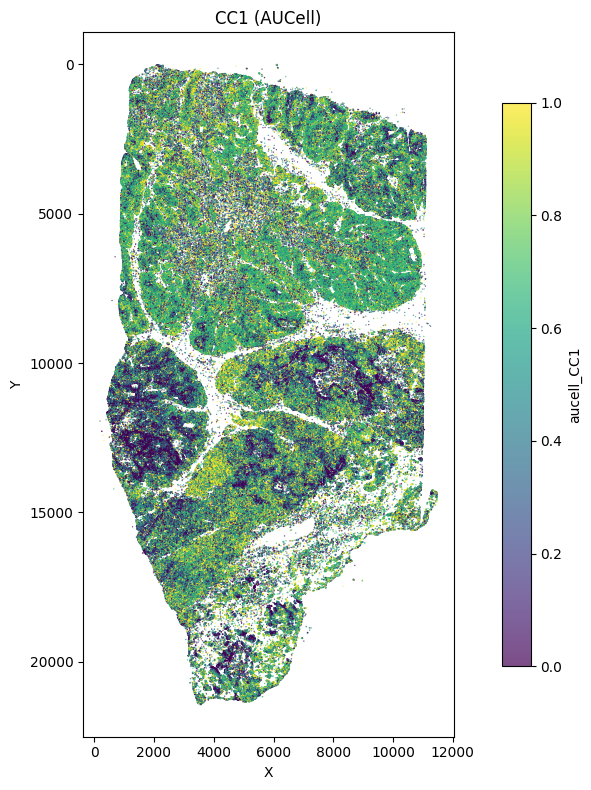

In [12]:
# Check what was stored in cell_meta
aucell_cols = [c for c in sp.cell_meta.columns if c.startswith("aucell_")]
print(f"AUCell columns in cell_meta: {aucell_cols}")

# Spatial plot of CC1 (only available in cancer cells)
sj.visualization.xenium_plot_spatial(sp, "aucell_CC1", kind="continuous",title="CC1 (AUCell)", 
                                     filename='Dotplot_CC1_AUCELL_Cancer_Cells.png', 
                                     save_dir='xenium_plots', show=True)

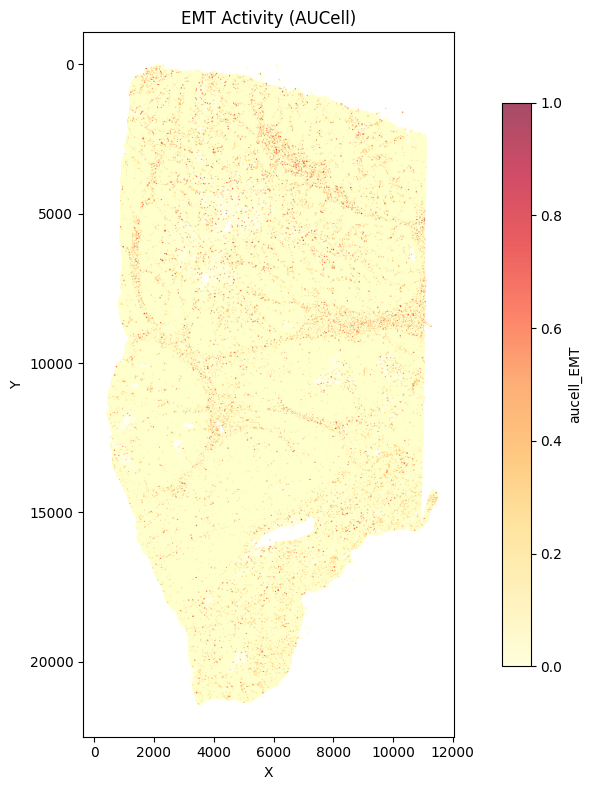

In [11]:
# Spatial plot of EMT activity
sj.visualization.xenium_plot_spatial(sp, "aucell_EMT", cmap = 'YlOrRd' ,kind="continuous",title="EMT Activity (AUCell)", show=True)

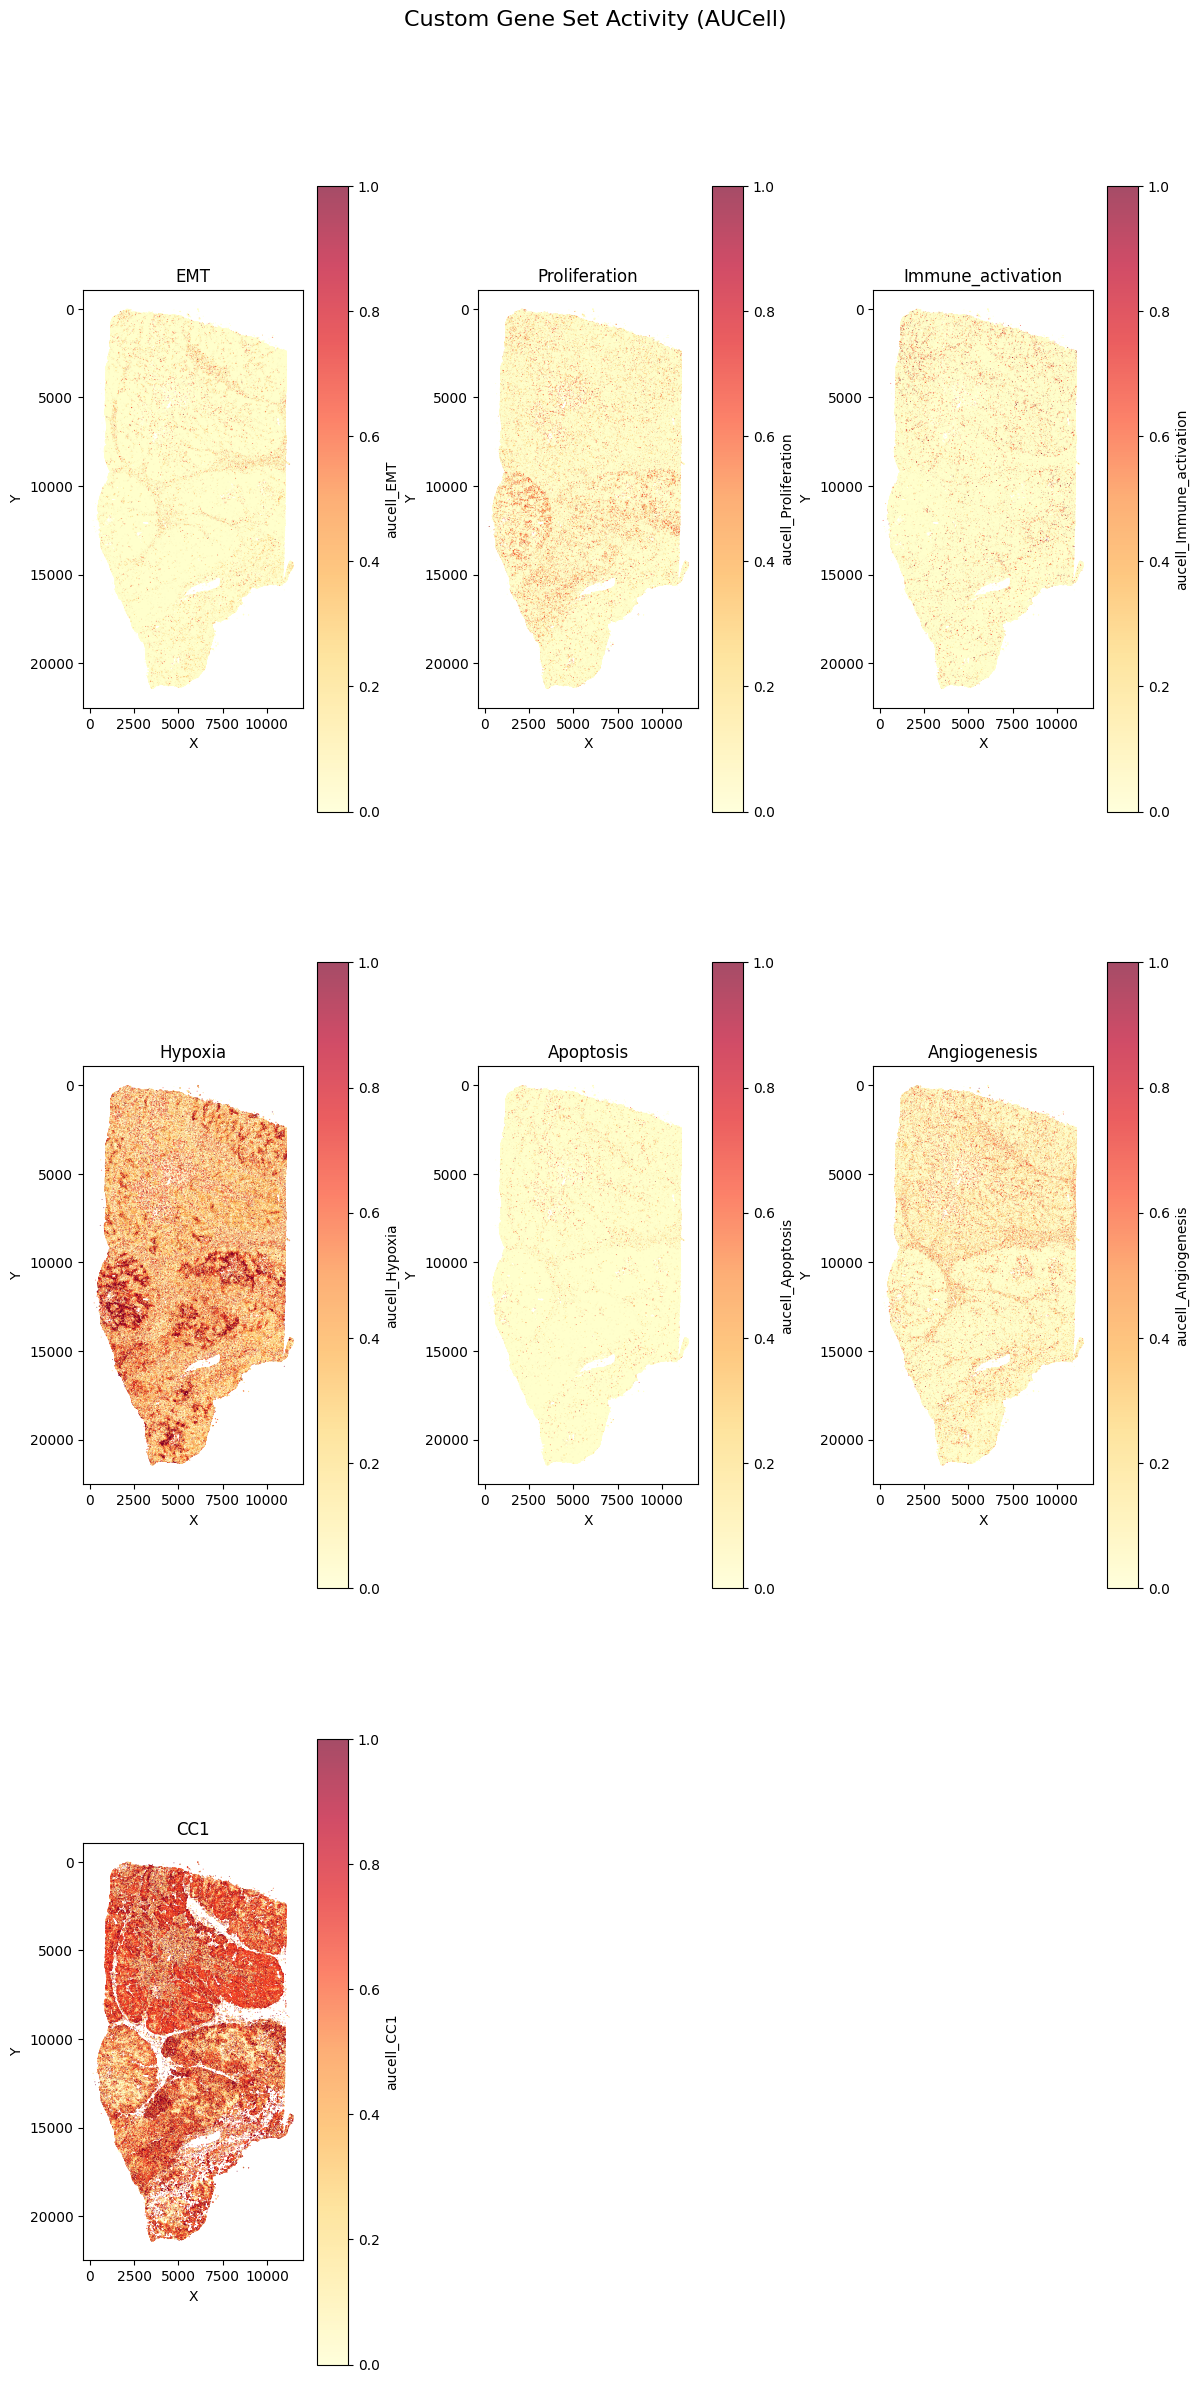

In [10]:
# Multi-panel: all custom gene sets side by side
gene_set_names = list(custom_gene_sets.keys())
n = len(gene_set_names)

fig, axes = plt.subplots(3, 3, figsize=(12, 24))

for i, (ax, name) in enumerate(zip(axes.flat, gene_set_names)):
  col = f"aucell_{name}"
  if col in sp.cell_meta.columns:
      sj.visualization.xenium_plot_spatial(
          sp, col, cmap="YlOrRd", ax=ax, show=False,
          title=name, dot_size=0.5
      )

# Hide empty subplots
for ax in axes.flat[len(gene_set_names):]:
  ax.set_visible(False)

plt.suptitle("Custom Gene Set Activity (AUCell)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Custom gene sets with weights

Some gene sets have direction (activation/inhibition). You can assign weights:
- Positive weight = gene is expected to be UP when the program is active
- Negative weight = gene is expected to be DOWN

In [ ]:
# # Weighted gene sets — some genes go UP, some go DOWN
# weighted_sets = {
#     "EMT_signed": ["VIM", "CDH2", "SNAI1", "CDH1", "EPCAM"],
# }
# weighted_weights = {
#     "EMT_signed": [1.0, 1.0, 1.0, -1.0, -1.0],  # CDH1, EPCAM go DOWN in EMT
# }

# # Convert to decoupler network format
# net_weighted = make_gene_set_net(weighted_sets, weights=weighted_weights)
# print(net_weighted)

# # Score with ULM (uses weights for direction)
# result_weighted = score_gene_sets(
#     sp, net_weighted, method="ulm", layer="log_normalized", store=True,
#     output_key="ulm_emt_estimate"
# )
# print(f"\nULM estimate shape: {result_weighted['estimate'].shape}")
# print(f"ULM p-values shape: {result_weighted['pvals'].shape}")

### 1.5 Load gene sets from a CSV/TSV file

If you have gene sets in a file, load them into the dict format first.

In [ ]:
# --- Option A: GMT format (one set per line: name \t description \t gene1 \t gene2 ...) ---
# This is the format used by MSigDB downloads
def load_gmt(path):
    """Load a .gmt file into a {name: [genes]} dict."""
    gene_sets = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split("\t")
            name = parts[0]
            genes = [g for g in parts[2:] if g]  # skip description (parts[1])
            gene_sets[name] = genes
    return gene_sets

# Usage:
# my_sets = load_gmt("path/to/msigdb_hallmarks.gmt")
# result = score_gene_sets(sp, my_sets, method="aucell")

# --- Option B: Long-format CSV (source, target, weight) ---
# Directly compatible with decoupler — no conversion needed
# net = pd.read_csv("my_gene_sets.csv")  # columns: source, target, weight
# result = score_gene_sets(sp, net, method="ulm")

# --- Option C: Wide-format CSV (gene_set, gene1, gene2, ...) ---
# Convert to dict first:
# df = pd.read_csv("wide_gene_sets.csv", index_col=0)
# my_sets = {row.name: row.dropna().tolist() for _, row in df.iterrows()}
# result = score_gene_sets(sp, my_sets, method="aucell")

print("See examples above for loading gene sets from files.")

---
## 2. Pre-defined Gene Sets

`load_gene_sets()` wraps decoupler's resource loaders. No manual download needed — everything is fetched automatically.

### 2.1 PROGENy — Signaling Pathway Activity

14 signaling pathways (EGFR, Hypoxia, JAK-STAT, MAPK, NFkB, p53, PI3K, TNFa, Trail, VEGF, WNT, TGFb, Androgen, Estrogen) with weighted gene contributions from large-scale perturbation data.

In [8]:
# Load PROGENy pathway signatures
progeny_net = load_gene_sets("progeny", organism="human")

# Inspect the network
print(f"\nNetwork shape: {progeny_net.shape}")
print(f"Columns: {list(progeny_net.columns)}")
print(f"\nPathways: {sorted(progeny_net['source'].unique())}")
print(f"\nSample rows:")
progeny_net.head(10)

  Loaded PROGENy: 14 pathways, 62421 interactions

Network shape: (62421, 4)
Columns: ['source', 'target', 'weight', 'padj']

Pathways: ['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53']

Sample rows:


,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
5,Androgen,SLC38A4,7.363805,1.253071e-39
6,Androgen,MTMR9,6.130646,2.534403e-38
7,Androgen,ZBTB16,10.614437,1.567152e-36
8,Androgen,KCNN2,9.473199,7.711872e-36
9,Androgen,OPRK1,-5.626074,1.114245e-35


In [9]:
# Score pathway activity — MLM recommended for PROGENy (weighted, multi-gene)
progeny_result = score_gene_sets(
    sp,
    net=progeny_net,
    method="mlm",              # multivariate linear model (uses weights) please use mlm
    layer="log_normalized",
    store=True,
)

# Activity scores per cell × pathway
progeny_result["estimate"].head()


[Decoupler] Scoring gene set activity (method=mlm)
  Gene overlap: 4705/17610 network targets found in expression
  Active sources (>= 5 targets): 14
  Subsetting expression to 4705 overlapping genes (saves memory)
  ✓ Scored 14 gene sets across 1134555 cells
  ✓ Stored in embeddings['mlm_estimate'] and cell_meta['mlm_*']


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:408: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:408: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:408: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
cell_id,,,,,,,,,,,,,,
aaaaapbh-1,1.121991,-2.666889,-1.674484,-1.769670,5.903053,2.497356,-5.408678,1.538556,0.948079,3.592074,-3.418502,2.127862,-0.013773,-8.341507
aaaabakn-1,0.198918,-1.660738,-1.882817,-2.087779,9.628237,0.761713,-7.416034,3.236588,0.859551,5.553690,-4.263182,2.469984,0.179918,-7.172519
aaaabhic-1,-1.126592,-2.278680,-2.155698,-1.435937,7.423319,0.794739,-6.107815,1.230802,0.290053,3.699976,-3.997528,2.798651,-0.824129,-6.045007
aaaabngi-1,0.531339,-2.722385,-1.507818,-2.677919,7.915149,2.503617,-6.587040,2.150144,1.004706,4.820618,-2.931204,1.270279,-0.909631,-9.132081
aaaabnhl-1,-0.353205,-1.611697,-2.979541,-1.030881,9.954474,0.735426,-5.145625,1.496420,1.394624,4.311968,-4.125090,3.898082,0.103043,-4.617039


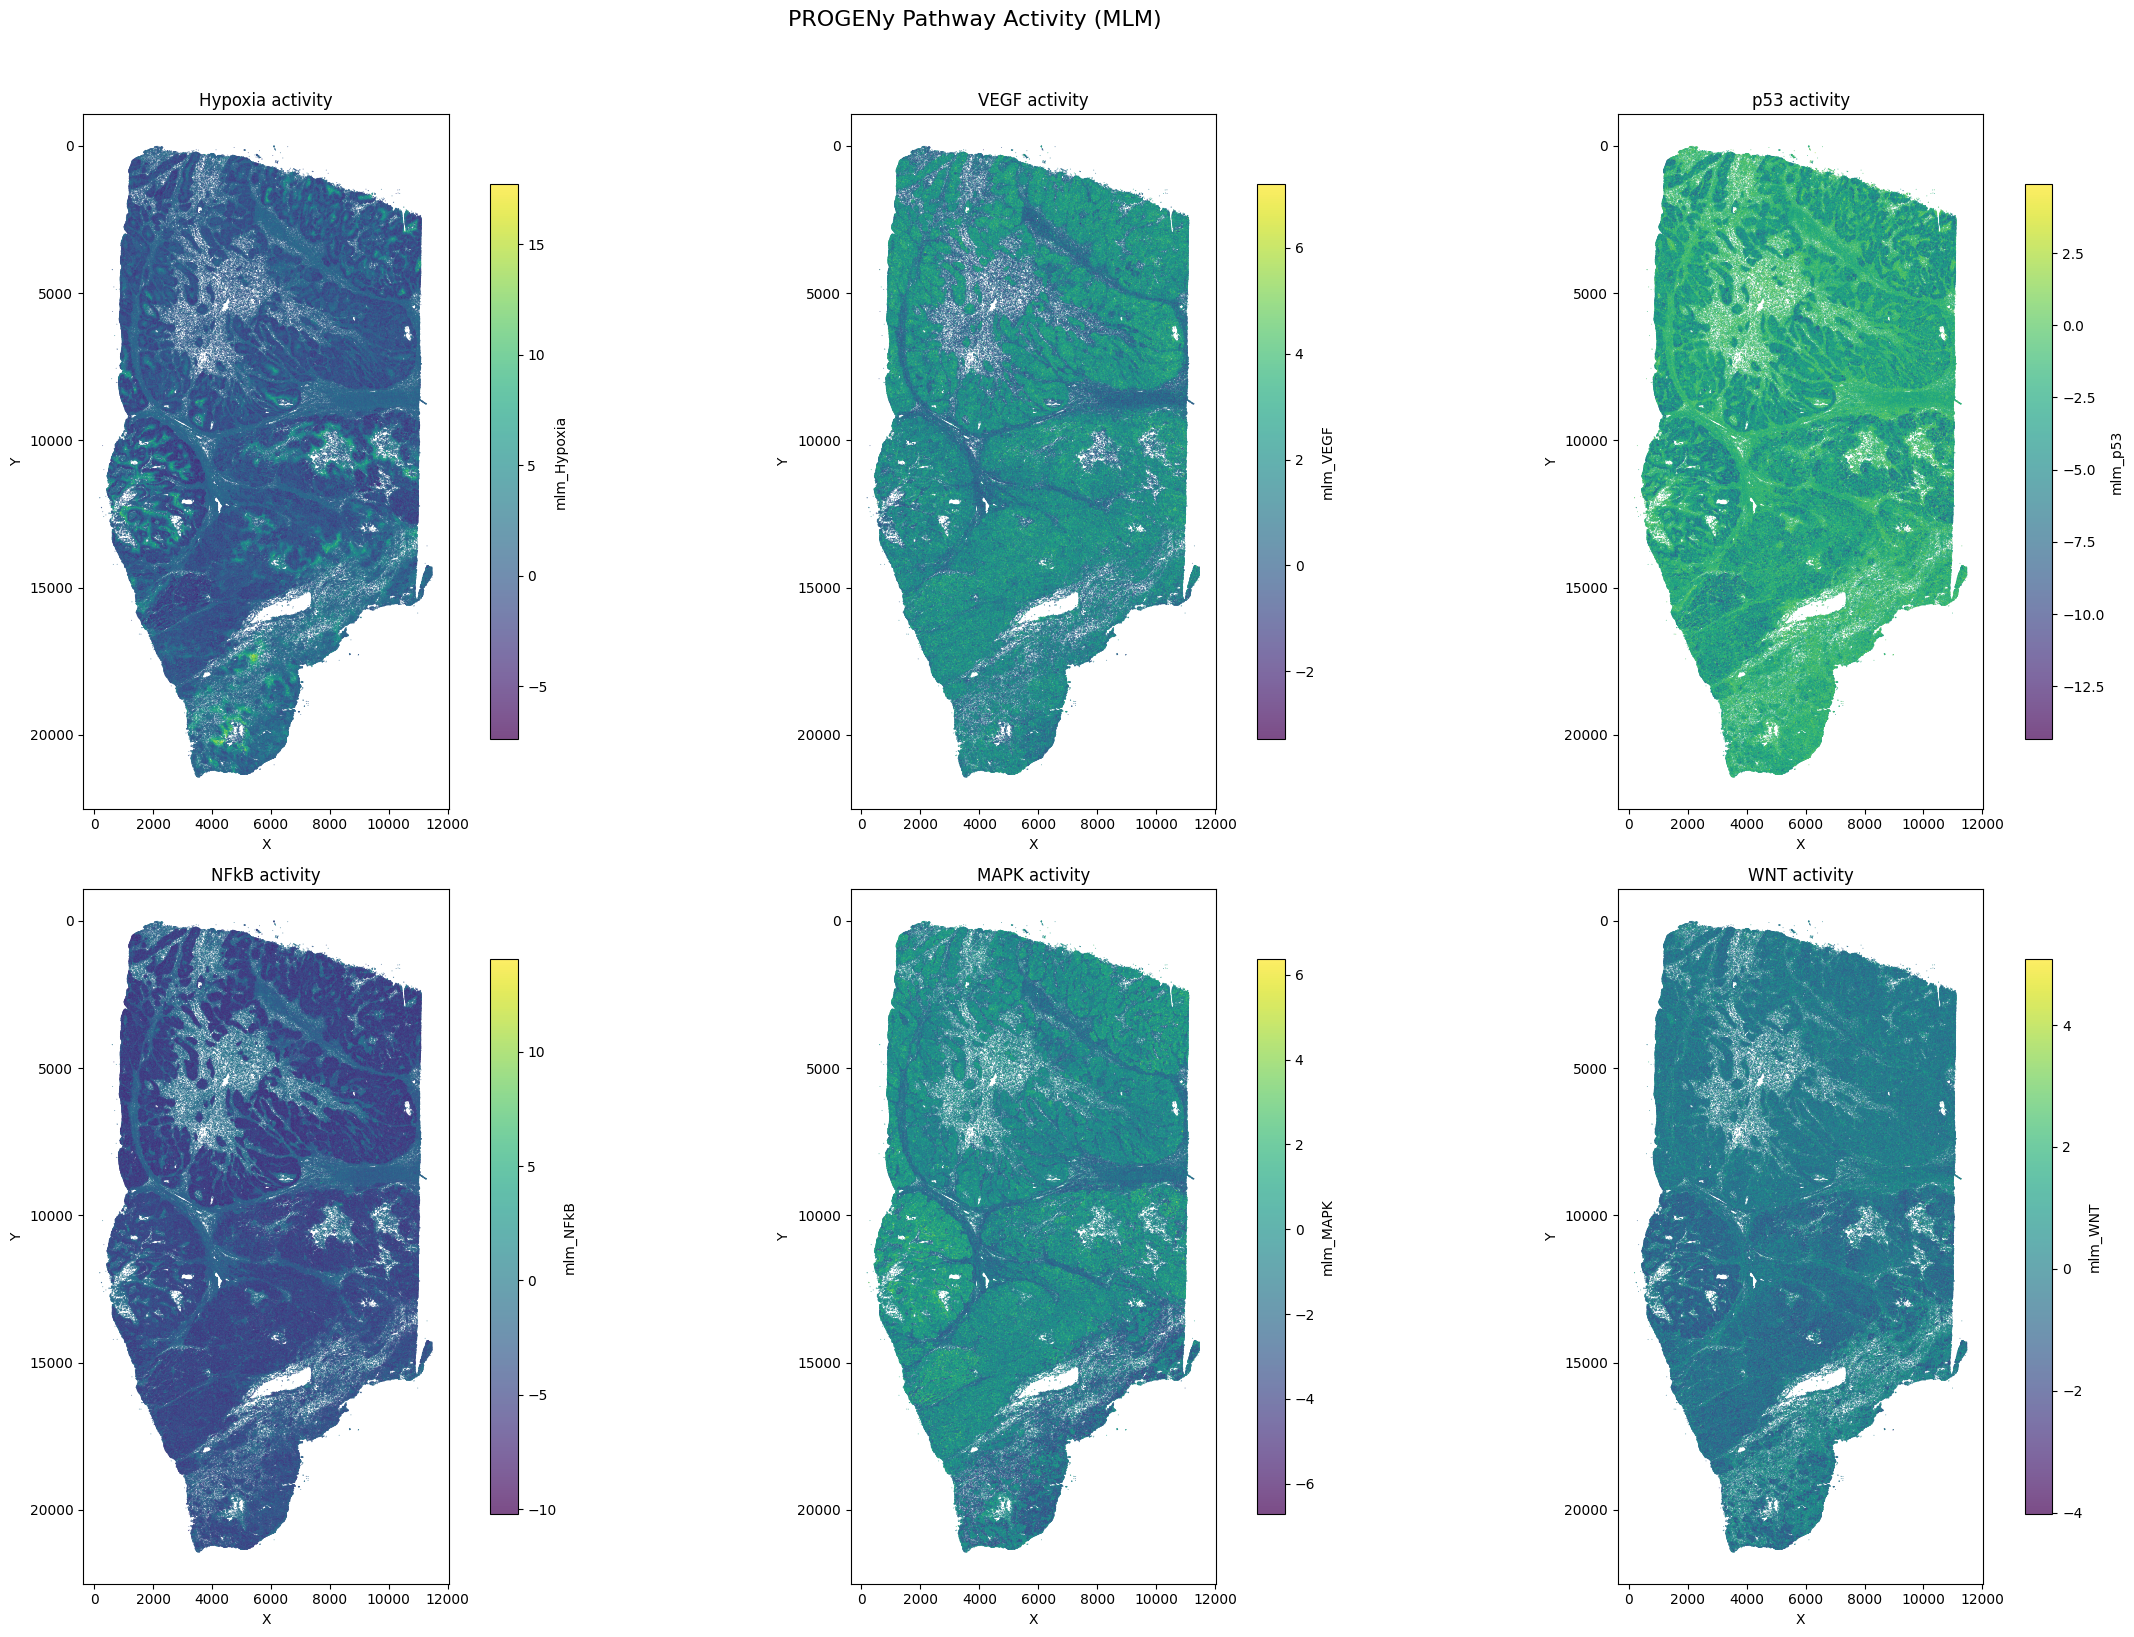

In [5]:
# Spatial visualization of pathway activities
pathways_to_plot = ["Hypoxia", "VEGF", "p53", "NFkB", "MAPK", "WNT"]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for ax, pathway in zip(axes.flat, pathways_to_plot):
    col = f"mlm_{pathway}"
    if col in sp.cell_meta.columns:
        sj.visualization.xenium_plot_spatial(
            sp, col, kind="continuous", ax=ax, show=False,
            title=f"{pathway} activity", dot_size=0.5
        )
plt.suptitle("PROGENy Pathway Activity (MLM)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 DoRothEA — Transcription Factor Activity

Infers TF activity from expression of their known target genes. Confidence levels:
- **A**: curated from literature (highest confidence)
- **B**: ChIP-seq supported
- **C**: in silico predicted (lower confidence)
- **D**: lowest confidence

Use levels A+B for stringent analysis, A+B+C for broader coverage.

In [6]:
# Load DoRothEA TF-target interactions (confidence A + B)
dorothea_net = load_gene_sets("dorothea", organism="human", levels=["A", "B"])
print(f"\nTop TFs by number of targets:")
print(dorothea_net.groupby("source").size().sort_values(ascending=False).head(15))

  Loaded DoRothEA (levels=['A', 'B']): 367 TFs, 15117 interactions

Top TFs by number of targets:
source
STAT1     721
CTCF      609
CEBPA     585
EGR1      559
HNF4A     550
ESR1      528
E2F1      524
ETS1      521
E2F4      508
FOXA1     502
TP53      502
GATA3     486
TFAP2C    480
GATA2     458
SPI1      444
dtype: int64


In [7]:
# Score TF activity — ULM recommended for DoRothEA
tf_result = score_gene_sets(
    sp,
    net=dorothea_net,
    method="ulm",
    layer="log_normalized",
    store=True,
    output_key="tf_ulm_estimate",
)

# Show top variable TFs across cells
tf_scores = tf_result["estimate"]
tf_std = tf_scores.std().sort_values(ascending=False)
print("Top 10 most variable TFs:")
print(tf_std.head(10))


[Decoupler] Scoring gene set activity (method=ulm)
  Gene overlap: 2083/5151 network targets found in expression
  Active sources (>= 5 targets): 321
  Subsetting expression to 2083 overlapping genes (saves memory)
  ✓ Scored 141 gene sets across 1134555 cells


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

  ✓ Stored in embeddings['tf_ulm_estimate'] and cell_meta['ulm_*']
Top 10 most variable TFs:
STAT2    2.261640
IRF9     1.839958
E2F4     1.804483
SPI1     1.695513
STAT1    1.689533
MYC      1.650649
ZEB1     1.596524
TFDP1    1.470048
IRF1     1.430396
IRF2     1.406527
dtype: float64


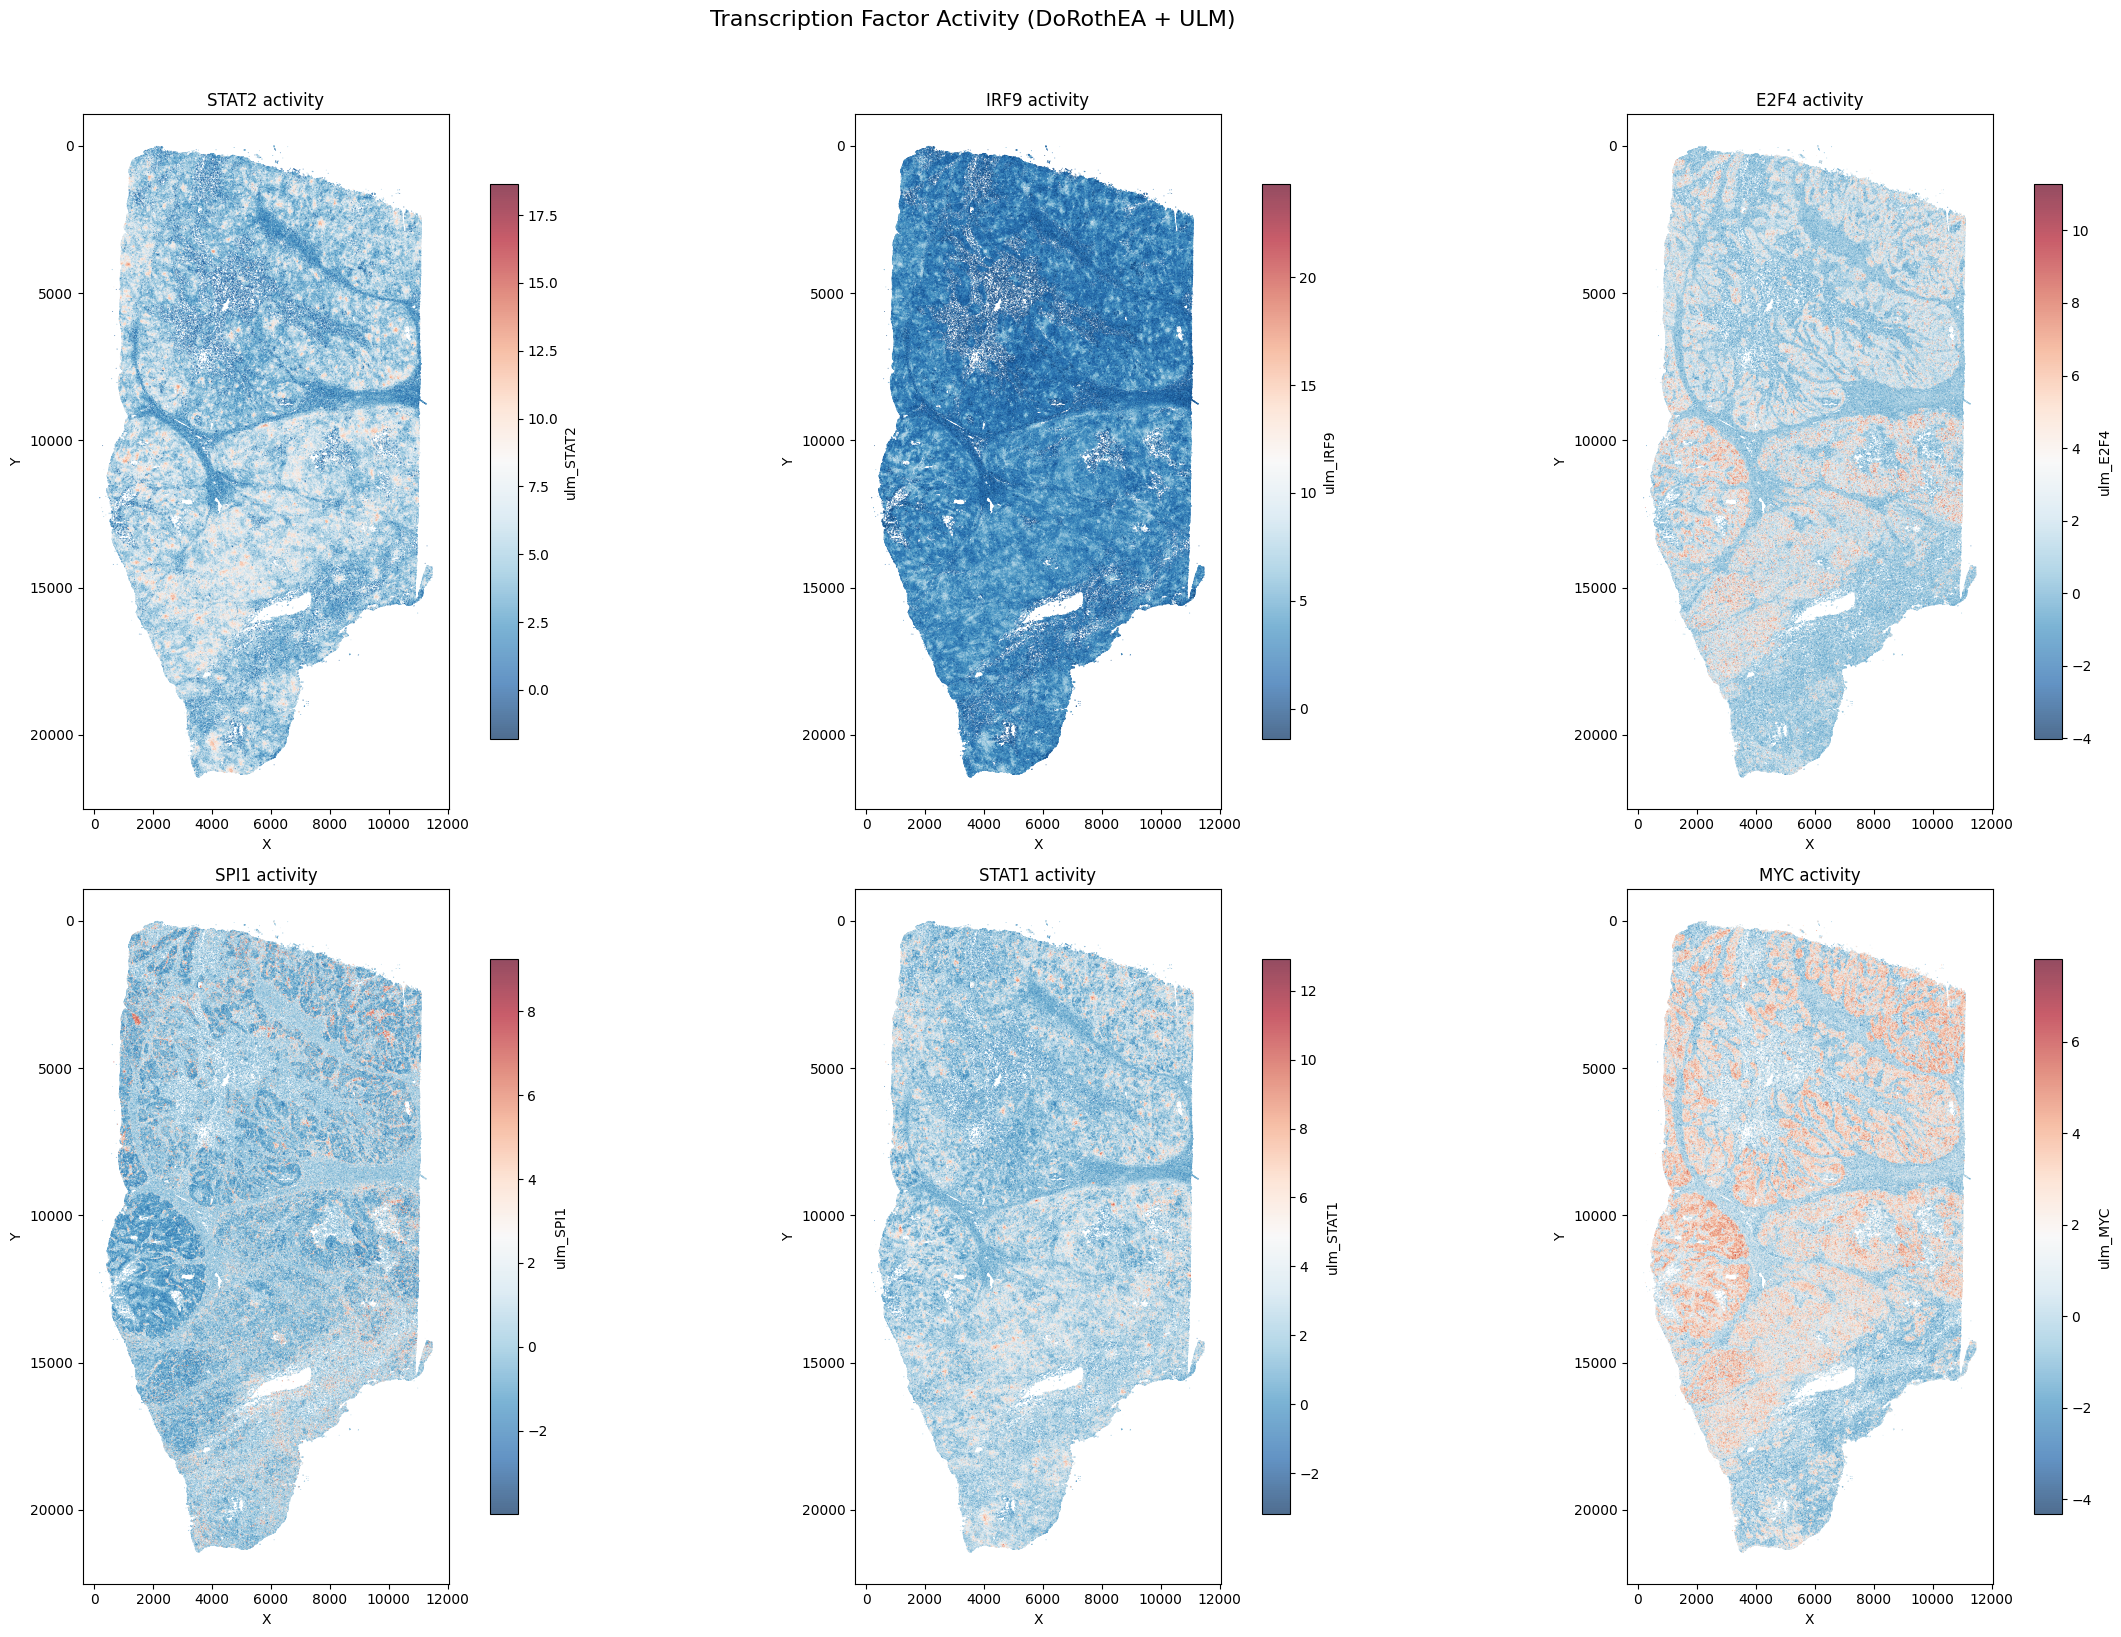

In [8]:
# Plot top variable TFs spatially
top_tfs = tf_std.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for ax, tf in zip(axes.flat, top_tfs):
    col = f"ulm_{tf}"
    if col in sp.cell_meta.columns:
        sj.visualization.xenium_plot_spatial(
            sp, col, cmap="RdBu_r", ax=ax, show=False,
            title=f"{tf} activity", dot_size=0.5,
        )
plt.suptitle("Transcription Factor Activity (DoRothEA + ULM)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 CollecTRI — Comprehensive TF Network

Alternative to DoRothEA with broader coverage (12 integrated resources).

In [9]:
# Load CollecTRI (broader TF network)
collectri_net = load_gene_sets("collectri", organism="human")
print(f"\nCollecTRI vs DoRothEA:")
print(f"  CollecTRI: {collectri_net['source'].nunique()} TFs, {len(collectri_net)} interactions")
print(f"  DoRothEA:  {dorothea_net['source'].nunique()} TFs, {len(dorothea_net)} interactions")

# Score with CollecTRI
collectri_result = score_gene_sets(sp, collectri_net, method="ulm", store=True)

  Loaded CollecTRI: 1185 TFs, 42990 interactions

CollecTRI vs DoRothEA:
  CollecTRI: 1185 TFs, 42990 interactions
  DoRothEA:  367 TFs, 15117 interactions

[Decoupler] Scoring gene set activity (method=ulm)
  Gene overlap: 2895/6675 network targets found in expression
  Active sources (>= 5 targets): 1100
  Subsetting expression to 2895 overlapping genes (saves memory)
  ✓ Scored 663 gene sets across 1134555 cells


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

  ✓ Stored in embeddings['ulm_estimate'] and cell_meta['ulm_*']


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp._cell_meta[col] = prefixed[col].values
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/processing/decoupler.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

In [11]:
collectri_result

{'estimate':                 ABL1       AHR      AHRR      AIRE       AP1     APEX1  \
 cell_id                                                                  
 aaaaapbh-1 -0.268914 -0.115351  0.735072 -1.190570 -1.653070  0.253246   
 aaaabakn-1  0.804902 -0.105648 -0.871612 -1.105659 -0.159225 -0.165679   
 aaaabhic-1  1.057501 -0.697226  1.161937 -0.111081 -1.330052  0.124456   
 aaaabngi-1 -1.465804 -0.855358 -0.034283 -1.372549 -2.184475  0.466488   
 aaaabnhl-1  0.232511 -1.081096 -1.043627 -1.078560 -1.694757 -0.247518   
 ...              ...       ...       ...       ...       ...       ...   
 oilncghd-1  0.290301  0.273452 -0.298336  1.227896  0.029406  0.857593   
 oilnefna-1 -0.652251 -0.284672 -1.375772  0.307991 -1.271709 -1.390400   
 oilnenmm-1 -0.167676 -0.901565 -0.082114 -0.338192 -1.690452 -0.479223   
 oilnfbml-1 -0.366731 -0.372024 -0.179592  0.472073 -0.351930  0.668946   
 oilngggn-1 -0.298050 -0.643055 -0.145959 -0.601169 -1.409762 -0.851901   
 
           

### 2.4 MSigDB — Molecular Signatures Database

The largest curated gene set collection. Includes hallmark, GO, KEGG, Reactome, and many more.

In [3]:
# Load MSigDB (takes a moment — large collection)
msigdb_net = load_gene_sets("MSigDB", organism="human")

# MSigDB has many sub-collections in the 'collection' column
print(f"\nMSigDB collections:")
if "collection" in msigdb_net.columns:
    print(msigdb_net["collection"].value_counts().head(20))
else:
    print(f"  Total gene sets: {msigdb_net['source'].nunique()}")

# Filter to just Hallmark gene sets (most commonly used)
if "collection" in msigdb_net.columns:
    hallmark_net = msigdb_net[msigdb_net["collection"] == "hallmark"].copy()
else:
    # If no collection column, filter by name prefix
    hallmark_net = msigdb_net[msigdb_net["source"].str.startswith("HALLMARK_")].copy()

print(f"\nHallmark gene sets: {hallmark_net['source'].nunique()}")
print(sorted(hallmark_net["source"].unique())[:10], "...")

  Loaded 'MSigDB': 35103 sets, 5895462 interactions

MSigDB collections:
collection
immunesigdb                           1234004
go_biological_process                 1027428
human_phenotype_ontology               801187
chemical_and_genetic_perturbations     564835
mirna_targets_mirdb                    478014
tf_targets_gtrf                        286911
reactome_pathways                      227377
cell_type_signatures                   208419
tf_targets_legacy                      203932
go_molecular_function                  194099
go_cellular_component                  192788
wikipathways                            77415
cancer_modules                          70575
vaccine_response                        60170
cancer_gene_neighborhoods               58664
mirna_targets_legacy                    45537
oncogenic_signatures                    39893
kegg_pathways                           28651
positional                              25017
kegg_medicus_pathways                   20

In [6]:
hallmark_net = hallmark_net.drop_duplicates(subset = ['source', 'target'])

In [7]:
# Score Hallmark gene sets with AUCell (unweighted → AUCell is ideal)
hallmark_result = score_gene_sets(
    sp,
    net=hallmark_net,
    method="aucell",
    layer="log_normalized",
    store=True,
)

# Show which hallmarks are most variable across cells
hallmark_std = hallmark_result["estimate"].std().sort_values(ascending=False)
print("Top 10 most spatially variable hallmark gene sets:")
for name, std_val in hallmark_std.head(10).items():
    print(f"  {name}: std = {std_val:.4f}")


[Decoupler] Scoring gene set activity (method=aucell)
  Gene overlap: 1859/6971 network targets found in expression
  Active sources (>= 5 targets): 50
  Subsetting expression to 1859 overlapping genes (saves memory)
  ✓ Scored 50 gene sets across 1134555 cells
  ✓ Stored in embeddings['aucell_estimate'] and cell_meta['aucell_*']
Top 10 most spatially variable hallmark gene sets:
  HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION: std = 0.0849
  HALLMARK_INTERFERON_GAMMA_RESPONSE: std = 0.0624
  HALLMARK_INTERFERON_ALPHA_RESPONSE: std = 0.0609
  HALLMARK_MYC_TARGETS_V1: std = 0.0578
  HALLMARK_ANGIOGENESIS: std = 0.0484
  HALLMARK_ALLOGRAFT_REJECTION: std = 0.0408
  HALLMARK_E2F_TARGETS: std = 0.0395
  HALLMARK_HYPOXIA: std = 0.0355
  HALLMARK_INFLAMMATORY_RESPONSE: std = 0.0354
  HALLMARK_UNFOLDED_PROTEIN_RESPONSE: std = 0.0349


---
## 3. Comparing Methods (optional and requires big mem)

Different methods suit different gene set types. Here we compare AUCell, ULM, and WMEAN on the same gene sets.

In [ ]:
# Compare 3 methods on PROGENy pathways
methods = ["aucell", "ulm", "wmean"]
results = {}

for m in methods:
    results[m] = score_gene_sets(
        sp, progeny_net, method=m,
        layer="log_normalized", store=False,
        n_permutations=100,  # fewer perms for speed in this demo
    )

# Compare a specific pathway across methods
pathway = "Hypoxia"  # change to any pathway of interest

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, m in zip(axes, methods):
    scores = results[m]["estimate"][pathway]
    coords = sp.get_spatial_coords(coord_type="global")
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=scores, cmap="RdBu_r",
                    s=0.5, alpha=0.7, linewidths=0)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"{pathway} — {m.upper()}")
    ax.axis("off")
    fig.colorbar(sc, ax=ax, shrink=0.8)

plt.suptitle(f"Method Comparison: {pathway} Pathway Activity", fontsize=14)
plt.tight_layout()
plt.show()


[Decoupler] Scoring gene set activity (method=aucell)
  Gene overlap: 4705/17610 network targets found in expression
  Active sources (>= 5 targets): 14
  Subsetting expression to 4705 overlapping genes (saves memory)
  ✓ Scored 14 gene sets across 1134555 cells

[Decoupler] Scoring gene set activity (method=ulm)
  Gene overlap: 4705/17610 network targets found in expression
  Active sources (>= 5 targets): 14
  Subsetting expression to 4705 overlapping genes (saves memory)
  ✓ Scored 14 gene sets across 1134555 cells

[Decoupler] Scoring gene set activity (method=wmean)
  Gene overlap: 4705/17610 network targets found in expression
  Active sources (>= 5 targets): 14
  Subsetting expression to 4705 overlapping genes (saves memory)


### 3.1 Consensus scoring (publication-quality)

Runs MLM + ULM + WMEAN and computes a consensus score across all three. Most robust but slowest.

In [ ]:
# Consensus scoring (runs 3 methods internally)
consensus_result = score_gene_sets(
    sp,
    net=progeny_net,
    method="consensus",
    layer="log_normalized",
    store=True,
    output_key="consensus_pathway",
)

consensus_result["estimate"].head()

---
## 4. Downstream Analysis

Once activity scores are in `sp.cell_meta`, you can use them with all spatioloji_s tools.

### 4.1 Activity by cell type — boxplot comparison

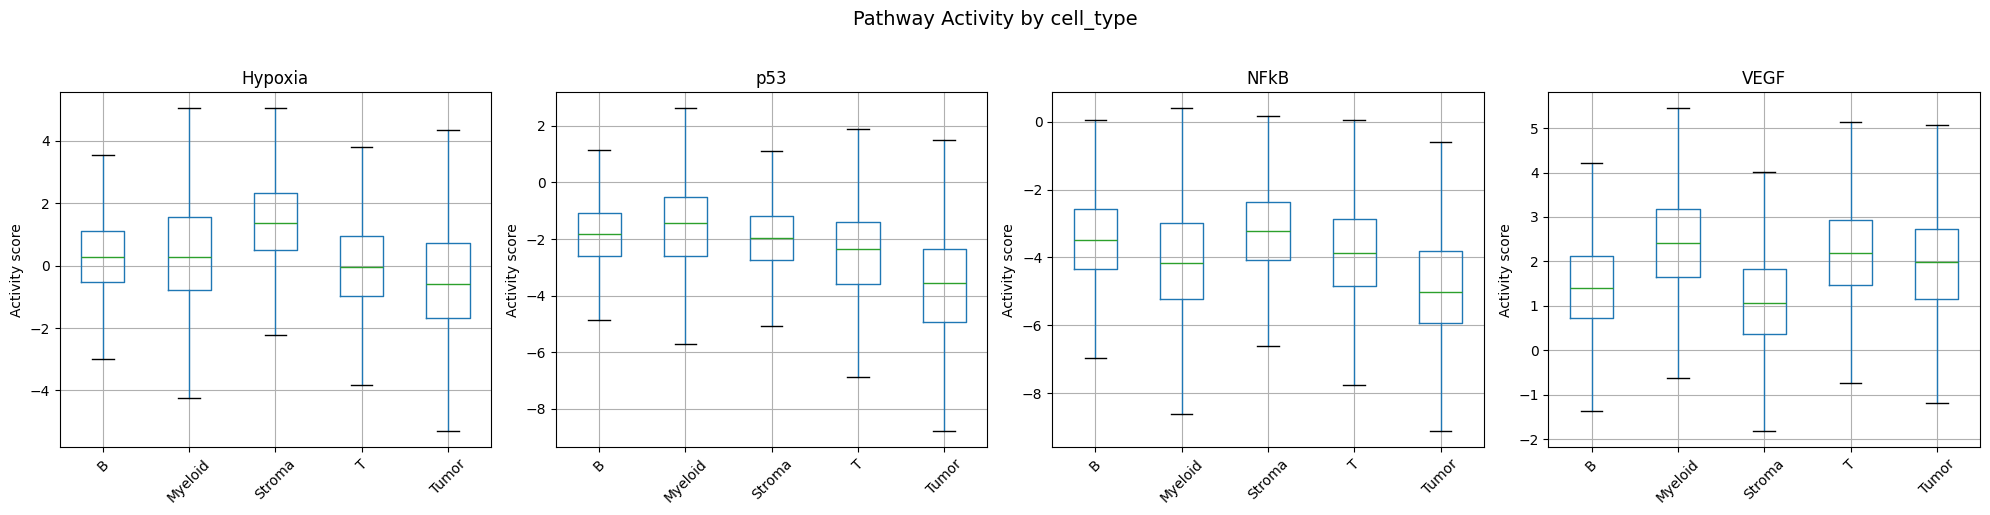

In [13]:
# Compare pathway activity across cell types
cell_type_col = "cell_type"  # change to your cell type column

# Pick a few pathways to compare
pathways = ["Hypoxia", "p53", "NFkB", "VEGF"]

fig, axes = plt.subplots(1, len(pathways), figsize=(5 * len(pathways), 5))
for ax, pathway in zip(axes, pathways):
    col = f"mlm_{pathway}"
    if col in sp.cell_meta.columns:
        data = sp.cell_meta[[cell_type_col, col]].dropna()
        data.boxplot(column=col, by=cell_type_col, ax=ax, rot=45, showfliers=False)
        ax.set_title(pathway)
        ax.set_xlabel("")
        ax.set_ylabel("Activity score")

plt.suptitle(f"Pathway Activity by {cell_type_col}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Spatial hotspot detection on pathway activity

Use Getis-Ord Gi* to find spatial clusters of high/low pathway activity.

In [11]:
# Build spatial graph
graph = sj.spatial.point.build_knn_graph(sp, k=10)

# Run Gi* hotspot detection on a pathway activity score
pathway_col = "mlm_Hypoxia"  # or any aucell_*, ulm_*, consensus_* column

gi_result = sj.spatial.point.getis_ord_gi(
    sp, graph,
    values=pathway_col,   # directly from cell_meta
    star=True,
    store=True,
)

print(f"\nHypoxia hotspots: {(gi_result['spot_type'] == 'hot').sum()} cells")
print(f"Hypoxia coldspots: {(gi_result['spot_type'] == 'cold').sum()} cells")

  ✓ KNN graph: k=10, 11345550 edges (directed), mean degree=10.0
  ✓ Getis-Ord Gi* (mlm_Hypoxia): 184092 hotspot cells, 266161 coldspot cells

Hypoxia hotspots: 0 cells
Hypoxia coldspots: 0 cells


/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/spatial/point/patterns.py:413: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sj.cell_meta[f"gi_{label}"] = gi
/carc/scratch/projects/amitra2016502/spatioloji_s/src/spatioloji_s/spatial/point/patterns.py:414: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sj.cell_meta[f"gi_{label}_spot"] = spot_type


### 4.3 Correlation between pathway activity and morphology

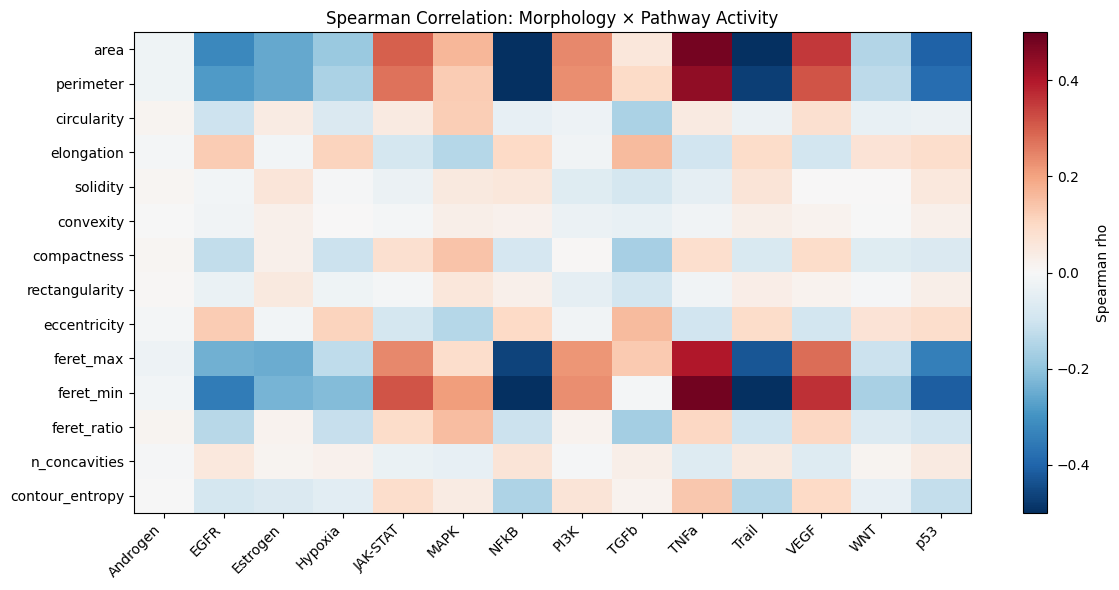

In [12]:
# Correlate pathway activity with cell morphology
# (requires compute_morphology to have been run)
morph_cols = [c for c in sp.cell_meta.columns if c.startswith("morph_") and c != "morph_class"]
pathway_cols = [c for c in sp.cell_meta.columns if c.startswith("mlm_")]

if morph_cols and pathway_cols:
    from scipy.stats import spearmanr
    
    corr_data = sp.cell_meta[morph_cols + pathway_cols].dropna()
    
    # Compute correlation matrix between morphology and pathway scores
    n_morph = len(morph_cols)
    n_path = len(pathway_cols)
    
    corr_matrix = np.zeros((n_morph, n_path))
    for i, mc in enumerate(morph_cols):
        for j, pc in enumerate(pathway_cols):
            rho, _ = spearmanr(corr_data[mc], corr_data[pc])
            corr_matrix[i, j] = rho
    
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
    ax.set_xticks(range(n_path))
    ax.set_xticklabels([c.replace("mlm_", "") for c in pathway_cols], rotation=45, ha="right")
    ax.set_yticks(range(n_morph))
    ax.set_yticklabels([c.replace("morph_", "") for c in morph_cols])
    ax.set_title("Spearman Correlation: Morphology × Pathway Activity")
    fig.colorbar(im, ax=ax, label="Spearman rho")
    plt.tight_layout()
    plt.show()
else:
    print("Run compute_morphology() and pathway scoring first.")

---
## 5. Quick Reference

```python
# ── Loading gene sets ──────────────────────────────────
from spatioloji_s.processing.decoupler import load_gene_sets, make_gene_set_net, score_gene_sets

# Pre-defined
net = load_gene_sets("progeny")                           # 14 signaling pathways
net = load_gene_sets("dorothea", levels=["A", "B"])       # TF activities
net = load_gene_sets("collectri")                         # comprehensive TF network
net = load_gene_sets("msigdb")                            # MSigDB (all collections)

# Custom — just a dict
net = {"EMT": ["VIM", "CDH2", "SNAI1"], "Prolif": ["MKI67", "TOP2A"]}

# Custom with weights
net = make_gene_set_net(
    {"EMT": ["VIM", "CDH1"]},
    weights={"EMT": [1.0, -1.0]}                          # CDH1 goes DOWN in EMT
)

# From GMT file
net = load_gmt("hallmarks.gmt")                           # see Section 1.5

# ── Scoring ────────────────────────────────────────────
result = score_gene_sets(sp, net, method="aucell")         # unweighted lists
result = score_gene_sets(sp, net, method="ulm")            # weighted, fast
result = score_gene_sets(sp, net, method="mlm")            # weighted, accurate
result = score_gene_sets(sp, net, method="wmean")           # permutation p-values
result = score_gene_sets(sp, net, method="consensus")       # multi-method consensus

# Results
result["estimate"]   # DataFrame: cells × gene sets
result["pvals"]      # DataFrame or None

# Stored in sp.cell_meta as method_SetName (e.g. aucell_EMT)
# Stored in sp._embeddings["aucell_estimate"]
```